In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from scipy.stats import kde

https://stackoverflow.com/questions/79493688/3d-scatter-plot-and-projected-kde-plots

/tmp/ipykernel_399/3577530249.py:17: DeprecationWarning: Please import `gaussian_kde` from the `scipy.stats` namespace; the `scipy.stats.kde` namespace is deprecated and will be removed in SciPy 2.0.0.
  kernel = kde.gaussian_kde(values)


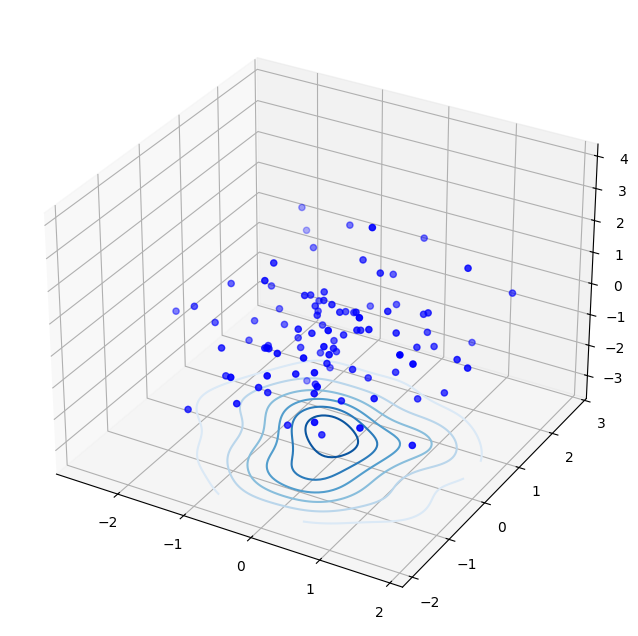

In [3]:

# Sample data
np.random.seed(42)
x = np.random.randn(100)
y = np.random.randn(100)
z = np.random.randn(100)

# Create figure and 3D axes
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(x, y, z, c='b', marker='o')

# KDE for projections
def kde_projection(data1, data2):
    values = np.vstack([data1, data2])
    kernel = kde.gaussian_kde(values)
    
    x_range = np.linspace(data1.min(), data1.max(), 100)
    y_range = np.linspace(data2.min(), data2.max(), 100)
    X, Y = np.meshgrid(x_range, y_range)
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kernel(positions).T, X.shape)
    return X, Y, Z

# Projections with KDE
# XY plane
X_xy, Y_xy, Z_xy = kde_projection(x, y)
ax.contour(X_xy, Y_xy, Z_xy, zdir='z', offset=z.min(), cmap='Blues')